In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from artifacts import process_results, compute_variable_stake, build_plot_df

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 1000)

ModuleNotFoundError: No module named 'artifacts'

In [25]:
def plot_strategy(df):
    # Create a line plot
    plt.figure(figsize=(10, 6))
    plt.plot(df.date, df.stake, linestyle='-', color='black')
    #plt.title('Cumulative Profits Over Time (%)')
    #plt.xlabel('Date')
    plt.ylabel('Portofolio')
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [12]:
sharpe_ratio_botorch = "artefacts/20240906041653"
df = pd.read_csv(f"{sharpe_ratio_botorch}/result_plot.csv")
df

,date,return,stake,n_favorable_bets
0,0,0.000000,1.000000,0
1,2023-04-15,0.633150,0.963315,88
2,2023-04-16,0.038135,0.870657,68
3,2023-04-22,1.213732,0.889266,84
4,2023-04-23,1.475857,0.931582,82
5,2023-04-29,0.940736,0.926061,74
6,2023-04-30,1.993474,1.018063,75
7,2023-05-07,1.138452,1.032158,87
8,2023-05-10,0.337402,0.963768,89
9,2023-05-11,1.224049,0.985361,78


In [5]:
plot_strategy(df)

NameError: name 'plot_strategy' is not defined

In [7]:
gamma_values

array([0.01, 0.04, 0.07, 0.1 , 0.13, 0.16, 0.19, 0.22, 0.25, 0.28, 0.31,
       0.34, 0.37, 0.4 , 0.43, 0.46, 0.49])

Biggest final stake: 1.1979135413561834 with gamma 0.01
Biggest final stake: 1.8516730562810846 with gamma 0.04
Biggest final stake: 2.5229864451884523 with gamma 0.07
Biggest final stake: 3.1148775182563755 with gamma 0.1
Biggest final stake: 3.544896409238087 with gamma 0.13
Biggest final stake: 3.761140650298816 with gamma 0.16


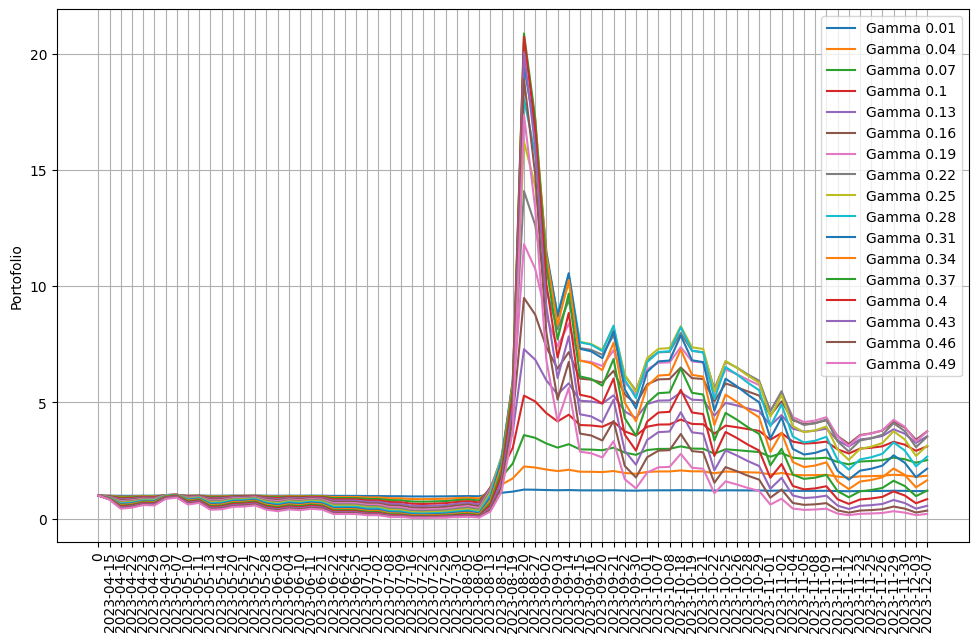

In [14]:
aggregator, do_baseline = 'Datetime', False
track_record = pd.read_csv(f"{sharpe_ratio_botorch}/result.csv")
track_record.columns = ['GameId', 'return',	'n_bets', 'n_favorable_bets', 'gamma', 'time_limit_flag', 'is_valid_solution', 'Datetime']

plt.figure(figsize=(10, 6))
plt.ylabel('Portofolio')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()

gamma_values = np.round(np.arange(0.01, 0.51, 0.03), 2)

biggest_final_stake = 0

for gamma in gamma_values:

    track_record["gamma"] = gamma
    df = process_results(aggregator, do_baseline, track_record)
    stake = compute_variable_stake(df)
    df_plot = build_plot_df(stake, do_baseline, df)

    if df_plot.stake.iloc[-1] > biggest_final_stake:
        biggest_final_stake = df_plot.stake.iloc[-1]
        print(f"Biggest final stake: {biggest_final_stake} with gamma {gamma}")

    plt.plot(df_plot.date, df_plot.stake, linestyle='-', label=f'Gamma {gamma}')

plt.legend()
plt.show()

In [13]:
gamma = 0.19
track_record["gamma"] = gamma
df = process_results(aggregator, do_baseline, track_record)
stake = compute_variable_stake(df)
df_plot = build_plot_df(stake, do_baseline, df)
print(df_plot)

          date     return      stake  n_favorable_bets
0            0   0.000000   1.000000                 0
1   2023-04-15   0.633150   0.930299                88
2   2023-04-16   0.038135   0.760282                68
3   2023-04-22   1.213732   0.791157                84
4   2023-04-23   1.475857   0.862687                82
5   2023-04-29   0.940736   0.852973                74
6   2023-04-30   1.993474   1.013981                75
7   2023-05-07   1.138452   1.040654                87
8   2023-05-10   0.337402   0.909643                89
9   2023-05-11   1.224049   0.948365                78
10  2023-05-13   0.120967   0.789973                78
11  2023-05-14   1.101549   0.805215                72
12  2023-05-20   1.514926   0.883994                83
13  2023-05-21   1.066564   0.895174                88
14  2023-05-27   1.185285   0.926688                79
15  2023-05-28   0.350414   0.812315                80
16  2023-06-03   0.663987   0.760455                90
17  2023-0

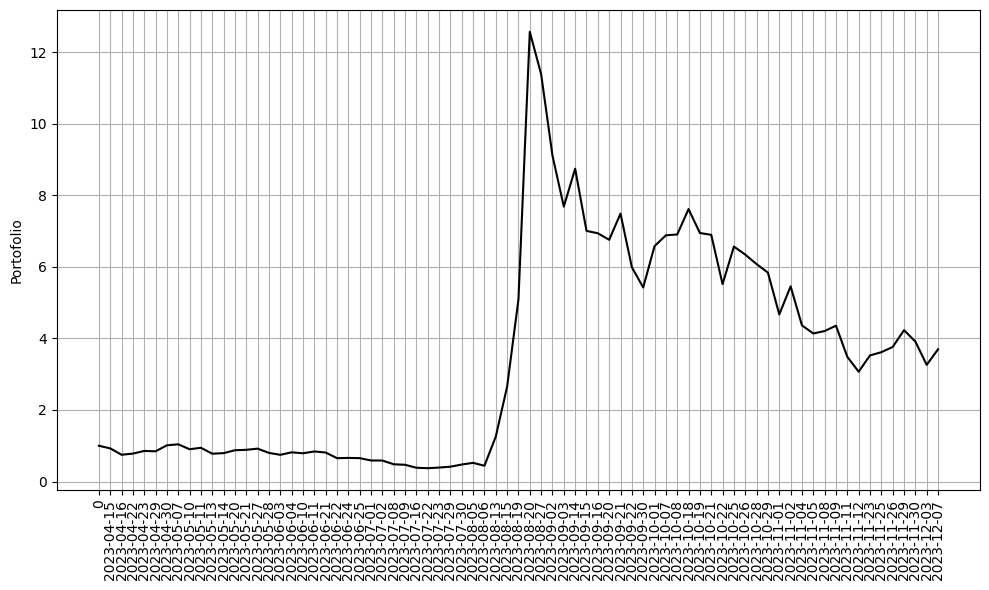

In [63]:
plot_strategy(df_plot)

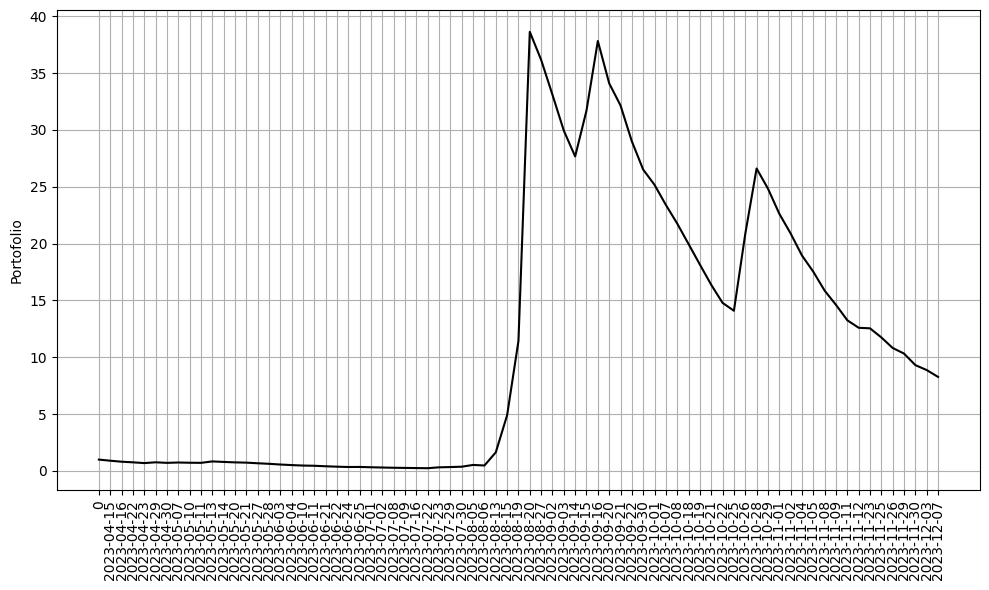

In [7]:
df_longterm = pd.read_csv("artefacts/20240905235851/result_plot.csv")
plot_strategy(df_longterm)

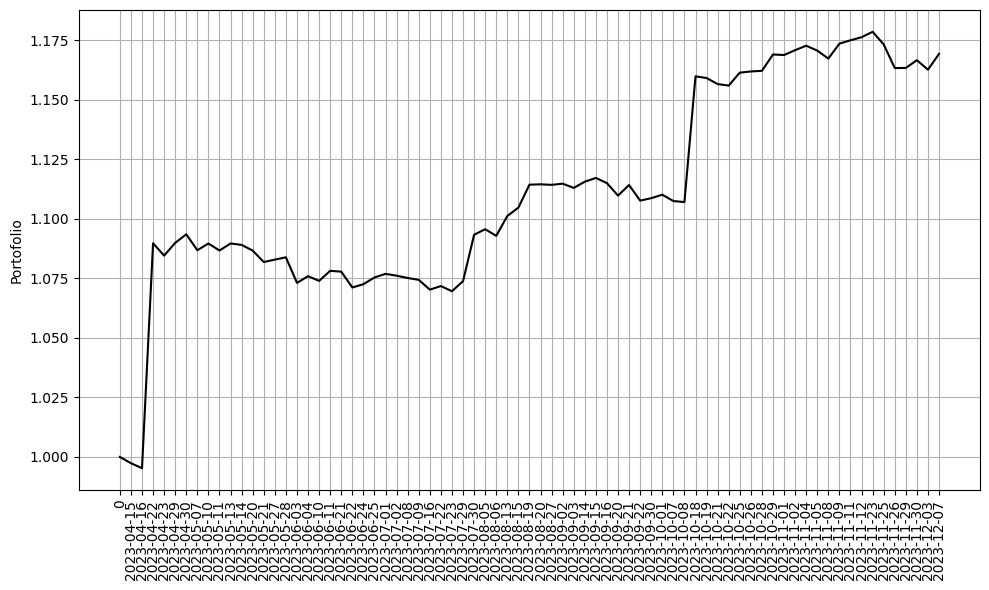

In [35]:
df_variable_stake = pd.read_csv("artefacts/20240905222241/result_plot.csv")
# df_variable_stake = pd.read_csv("artefacts/20240905222241/result.csv")
df_variable_stake

plot_strategy(df_variable_stake)

In [51]:
from artifacts import process_results, compute_variable_stake
aggregator = "Datetime"
do_baseline = False
track_record = pd.read_csv("artefacts/20240905222241/result.csv")
track_record.columns = ['GameId', 'return',	'n_bets', 'n_favorable_bets', 'gamma', 'time_limit_flag', 'is_valid_solution', 'Datetime']
df = process_results(aggregator, do_baseline, track_record)
stake = compute_variable_stake(df)

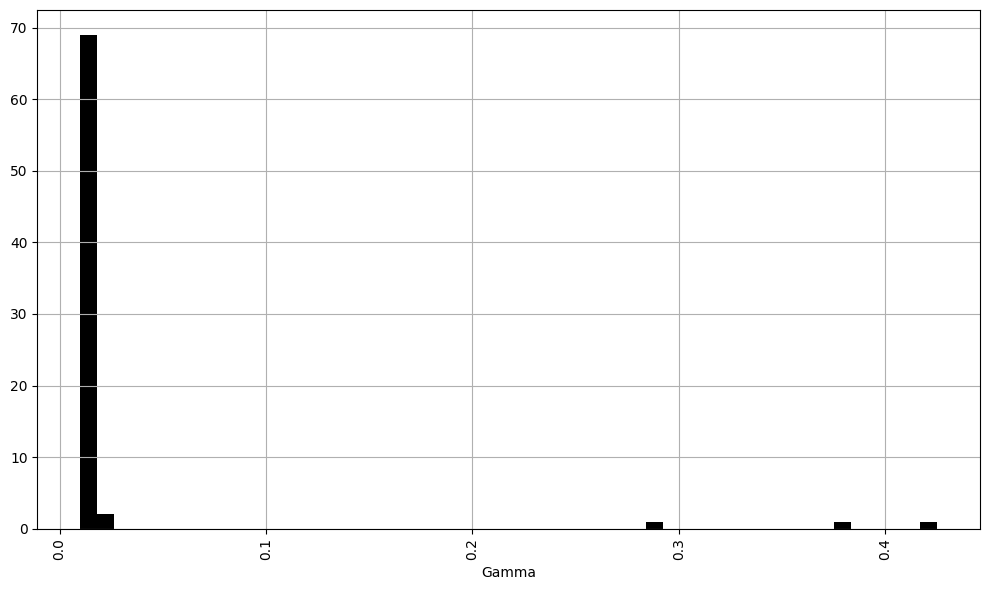

In [54]:
plt.figure(figsize=(10, 6))
plt.hist(df.gamma, bins=50, color="black")
plt.xlabel('Gamma')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

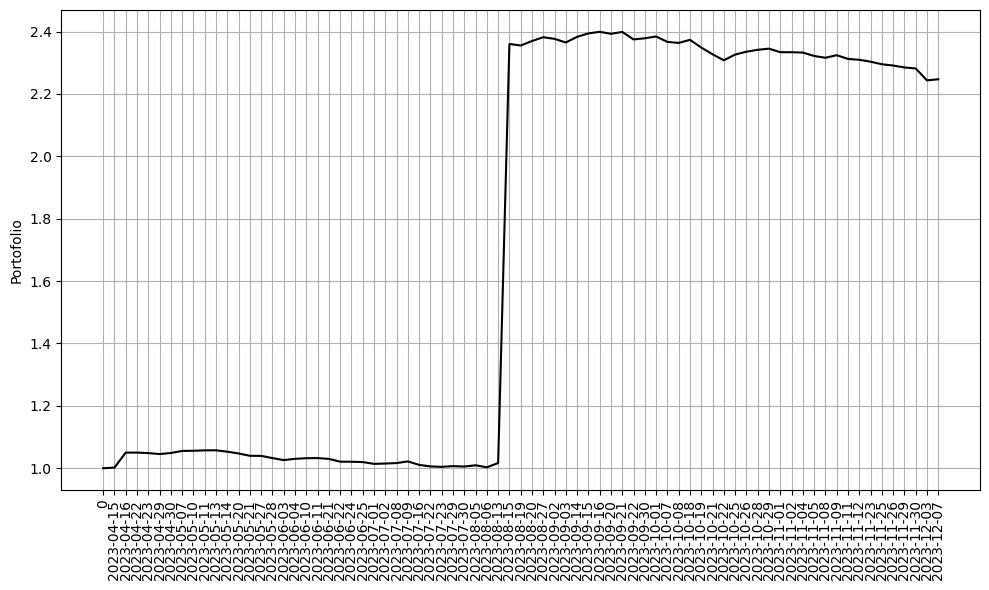

In [106]:
df_variable_stake_median = pd.read_csv("artefacts/20240906060955/result_plot.csv")
plot_strategy(df_variable_stake_median)

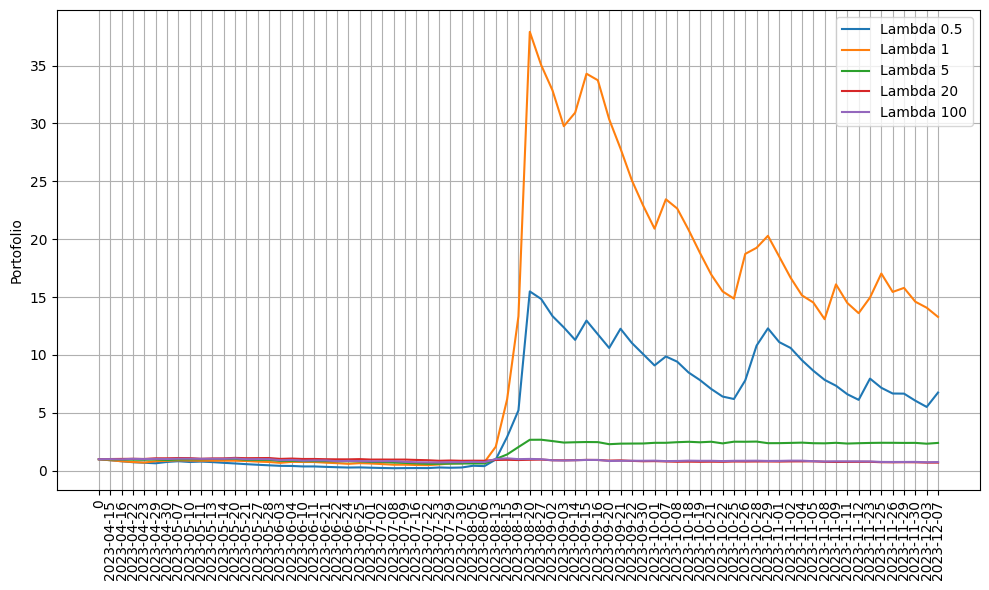

In [42]:
df_lambda_1 = pd.read_csv("artefacts/20240906043045/result_plot.csv")
df_lambda_point_5 = pd.read_csv("artefacts/20240906044331/result_plot.csv")
df_lambda_20 = pd.read_csv("artefacts/20240906044042/result_plot.csv")
df_lambda_100 = pd.read_csv("artefacts/20240906043737/result_plot.csv")
df_lambda_5 = pd.read_csv("artefacts/20240906043432/result_plot.csv")

# Create a line plot
plt.figure(figsize=(10, 6))
plt.plot(df_lambda_point_5.date, df_lambda_point_5.stake, label='Lambda 0.5', linestyle='-')
plt.plot(df_lambda_1.date, df_lambda_1.stake, label='Lambda 1', linestyle='-')
plt.plot(df_lambda_5.date, df_lambda_5.stake, label='Lambda 5', linestyle='-')
plt.plot(df_lambda_20.date, df_lambda_20.stake, label='Lambda 20', linestyle='-')
plt.plot(df_lambda_100.date, df_lambda_100.stake, label='Lambda 100', linestyle='-')
#plt.title('Cumulative Profits Over Time (%)')


#plt.xlabel('Date')
plt.ylabel('Portofolio')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()